# Project 4: Executive Data Visualization and Storytelling

This notebook turns the e-commerce orders dataset into a concise executive story. The emphasis is explanatory visualization: each chart is designed to support one business-facing message rather than to exhaustively explore every variable.

**Analyst note:** The dataset contains gross order value only. It does not include cost, margin, advertising spend, cancellation reason, or fulfillment timestamps, so all findings are descriptive and should not be interpreted as profitability or causal claims.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Presentation generation
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN, MSO_AUTO_SIZE
from pptx.enum.shapes import MSO_SHAPE

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'Dataset for Data Analytics.xlsx'
VISUAL_DIR = BASE_DIR / 'visuals'
PRESENTATION_DIR = BASE_DIR / 'presentation'
REPORTS_DIR = BASE_DIR / 'reports'

for directory in [VISUAL_DIR, PRESENTATION_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 220,
    'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.edgecolor': '#D5D8DC',
    'grid.color': '#E8EAED',
    'grid.linewidth': 0.8,
})

PALETTE = {
    'ink': '#1F2933',
    'muted': '#667085',
    'blue': '#276EF1',
    'teal': '#0E9384',
    'gold': '#B7791F',
    'red': '#C2410C',
    'green': '#257A4F',
    'gray': '#AAB2BD',
    'paper': '#FAF9F6',
}

def money_millions(x, pos=None):
    return f'${x/1_000_000:.1f}M' if abs(x) >= 1_000_000 else f'${x/1_000:.0f}K'

def money_short(value):
    return f'${value/1_000:.1f}K'

def pct(value):
    return f'{value:.1%}'

## 1. Load and Prepare the Dataset

The project uses the provided Excel dataset only. Preparation is limited to type checks, a revenue formula validation, and story-level fields such as order month and status group.

In [2]:
df = pd.read_excel(DATA_PATH)

expected_columns = {
    'OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
    'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
    'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'
}
missing = expected_columns - set(df.columns)
if missing:
    raise ValueError(f'Missing expected columns: {sorted(missing)}')

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp()
df['RevenueCheck'] = (df['Quantity'] * df['UnitPrice']).round(2)
df['RevenueVariance'] = (df['TotalPrice'] - df['RevenueCheck']).round(2)

status_group_map = {
    'Delivered': 'Fulfilled',
    'Shipped': 'Fulfilled',
    'Pending': 'Pending',
    'Cancelled': 'Cancelled',
    'Returned': 'Returned',
}
df['StatusGroup'] = df['OrderStatus'].map(status_group_map).fillna(df['OrderStatus'])

summary = {
    'rows': len(df),
    'date_min': df['Date'].min().date().isoformat(),
    'date_max': df['Date'].max().date().isoformat(),
    'gross_revenue': df['TotalPrice'].sum(),
    'unique_products': df['Product'].nunique(),
    'unique_referral_sources': df['ReferralSource'].nunique(),
    'max_revenue_variance': df['RevenueVariance'].abs().max(),
}
summary

{'rows': 1200,
 'date_min': '2023-01-01',
 'date_max': '2025-06-30',
 'gross_revenue': np.float64(1264761.96),
 'unique_products': 7,
 'unique_referral_sources': 5,
 'max_revenue_variance': np.float64(0.0)}

**Analyst note:** The dataset has no literal `Completed` order status. To avoid inventing values, this notebook shows the original statuses and uses `Delivered` + `Shipped` only as a supporting fulfilled-status grouping where needed.

In [3]:
quality_table = pd.DataFrame({
    'Check': [
        'Rows loaded',
        'Date range',
        'Total gross revenue',
        'Maximum TotalPrice variance vs Quantity x UnitPrice',
        'Original order statuses',
    ],
    'Result': [
        f"{summary['rows']:,}",
        f"{summary['date_min']} to {summary['date_max']}",
        f"${summary['gross_revenue']:,.2f}",
        f"${summary['max_revenue_variance']:,.2f}",
        ', '.join(sorted(df['OrderStatus'].unique())),
    ]
})
quality_table

,Check,Result
0,Rows loaded,"1,200"
1,Date range,2023-01-01 to 2025-06-30
2,Total gross revenue,"$1,264,761.96"
3,Maximum TotalPrice variance vs Quantity x Unit...,$0.00
4,Original order statuses,"Cancelled, Delivered, Pending, Returned, Shipped"


## 2. Revenue Performance

**Story message:** Gross revenue is uneven month to month, with visible peaks rather than a sustained upward trend.

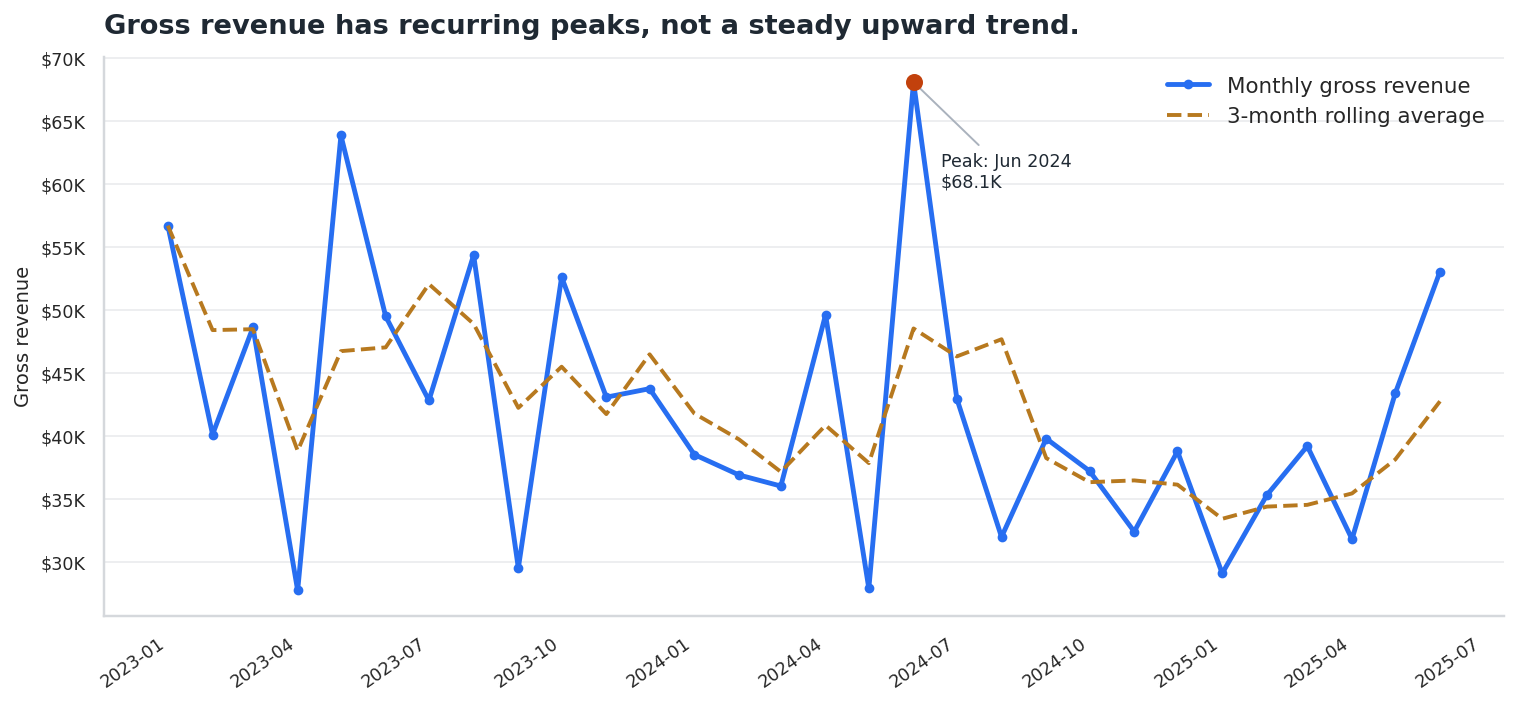

,Month,GrossRevenue,Orders,Rolling3M
22,2024-11-01,32413.76,35,36478.570000
23,2024-12-01,38785.77,41,36142.166667
24,2025-01-01,29099.40,27,33432.976667
25,2025-02-01,35317.55,37,34400.906667
26,2025-03-01,39200.66,49,34539.203333
27,2025-04-01,31821.20,32,35446.470000
28,2025-05-01,43396.64,37,38139.500000
29,2025-06-01,53047.40,49,42755.080000


In [4]:
monthly = (
    df.groupby('Month', as_index=False)
      .agg(GrossRevenue=('TotalPrice', 'sum'), Orders=('OrderID', 'count'))
      .sort_values('Month')
)
monthly['Rolling3M'] = monthly['GrossRevenue'].rolling(3, min_periods=1).mean()
peak_month = monthly.loc[monthly['GrossRevenue'].idxmax()]
recent_month = monthly.iloc[-1]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(monthly['Month'], monthly['GrossRevenue'], color=PALETTE['blue'], linewidth=2.5, marker='o', markersize=4)
ax.plot(monthly['Month'], monthly['Rolling3M'], color=PALETTE['gold'], linewidth=2, linestyle='--')
ax.scatter([peak_month['Month']], [peak_month['GrossRevenue']], color=PALETTE['red'], s=60, zorder=5)
ax.annotate(
    f"Peak: {peak_month['Month']:%b %Y}\n{money_short(peak_month['GrossRevenue'])}",
    xy=(peak_month['Month'], peak_month['GrossRevenue']),
    xytext=(14, -36),
    textcoords='offset points',
    fontsize=9,
    va='top',
    color=PALETTE['ink'],
    arrowprops=dict(arrowstyle='-', color=PALETTE['gray'], lw=1),
)
ax.set_title('Gross revenue has recurring peaks, not a steady upward trend.', loc='left', color=PALETTE['ink'], pad=12)
ax.set_xlabel('')
ax.set_ylabel('Gross revenue')
ax.yaxis.set_major_formatter(FuncFormatter(money_millions))
ax.grid(axis='x', visible=False)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(['Monthly gross revenue', '3-month rolling average'], frameon=False, loc='upper right')
fig.autofmt_xdate(rotation=35, ha='right')
fig.tight_layout()
revenue_visual = VISUAL_DIR / '01_monthly_revenue_trend.png'
fig.savefig(revenue_visual, bbox_inches='tight', facecolor='white')
plt.show()

monthly[['Month', 'GrossRevenue', 'Orders', 'Rolling3M']].tail(8)

**Analyst note:** This chart uses gross order value from all statuses. Net revenue would require a policy for cancelled, returned, and pending orders that is not present in the dataset.

## 3. Product Performance

**Story message:** Chair and Printer lead gross revenue, while the top three products account for a large but not overwhelming share of sales.

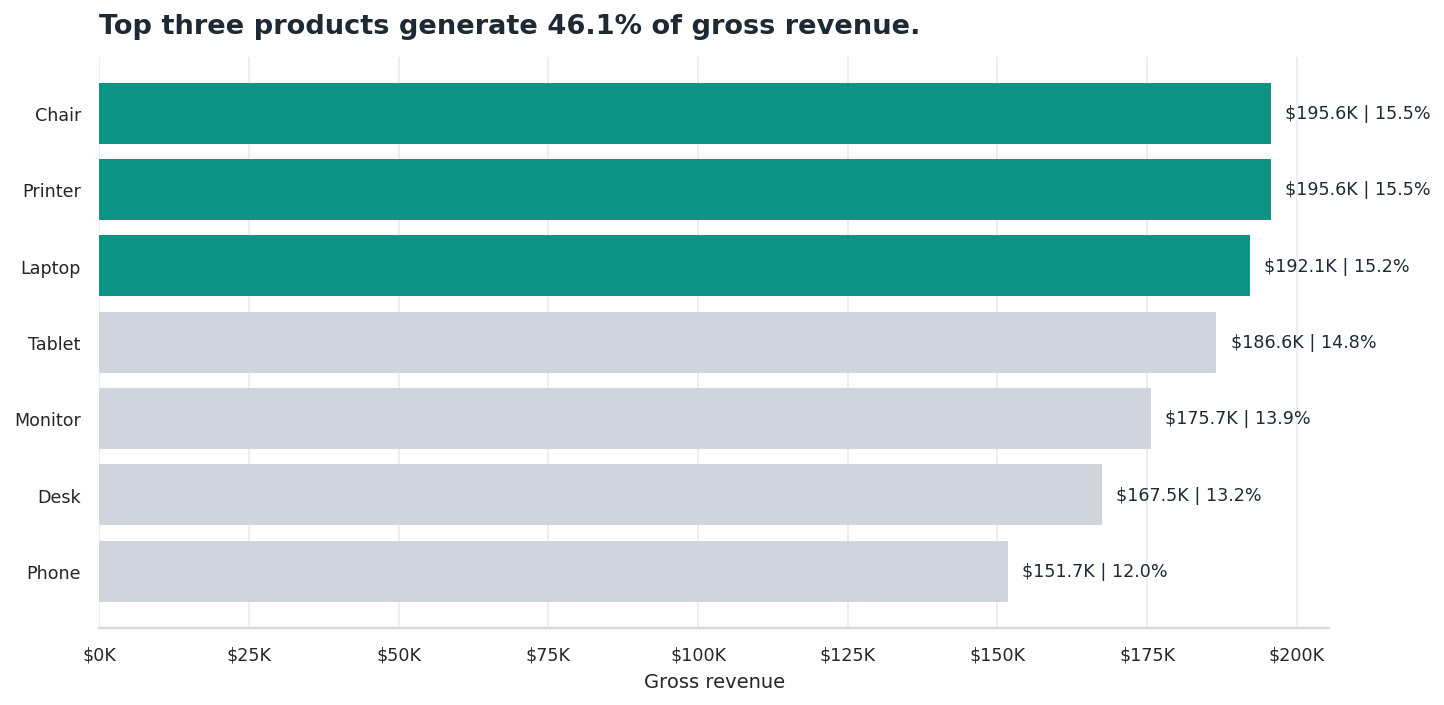

,Product,GrossRevenue,Orders,Units,RevenueShare,CumulativeShare
0,Chair,195620.11,178,562,0.154670,0.154670
5,Printer,195612.61,181,542,0.154664,0.309333
2,Laptop,192126.56,173,535,0.151907,0.461240
6,Tablet,186568.95,179,497,0.147513,0.608753
3,Monitor,175651.41,163,480,0.138881,0.747634
1,Desk,167459.93,170,508,0.132404,0.880039
4,Phone,151722.39,156,411,0.119961,1.000000


In [5]:
product = (
    df.groupby('Product', as_index=False)
      .agg(GrossRevenue=('TotalPrice', 'sum'), Orders=('OrderID', 'count'), Units=('Quantity', 'sum'))
      .sort_values('GrossRevenue', ascending=False)
)
product['RevenueShare'] = product['GrossRevenue'] / product['GrossRevenue'].sum()
product['CumulativeShare'] = product['RevenueShare'].cumsum()
top3_share = product.head(3)['RevenueShare'].sum()

fig, ax = plt.subplots(figsize=(10.5, 5.2))
colors = [PALETTE['teal'] if i < 3 else '#D0D5DD' for i in range(len(product))]
bars = ax.barh(product['Product'], product['GrossRevenue'], color=colors, edgecolor='none')
ax.invert_yaxis()
ax.set_title(f'Top three products generate {top3_share:.1%} of gross revenue.', loc='left', color=PALETTE['ink'], pad=12)
ax.set_xlabel('Gross revenue')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(money_millions))
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
for bar, value, share in zip(bars, product['GrossRevenue'], product['RevenueShare']):
    ax.text(value + product['GrossRevenue'].max()*0.012, bar.get_y() + bar.get_height()/2,
            f'{money_short(value)} | {share:.1%}', va='center', fontsize=9, color=PALETTE['ink'])
fig.tight_layout()
product_visual = VISUAL_DIR / '02_product_revenue_ranking.png'
fig.savefig(product_visual, bbox_inches='tight', facecolor='white')
plt.show()

product

**Analyst note:** The product ranking is based on revenue only. Profitability cannot be inferred because cost of goods sold and discount expense are unavailable.

## 4. Referral Source Performance

**Story message:** Instagram is the leading referral source by gross revenue, but the gap to Email is modest.

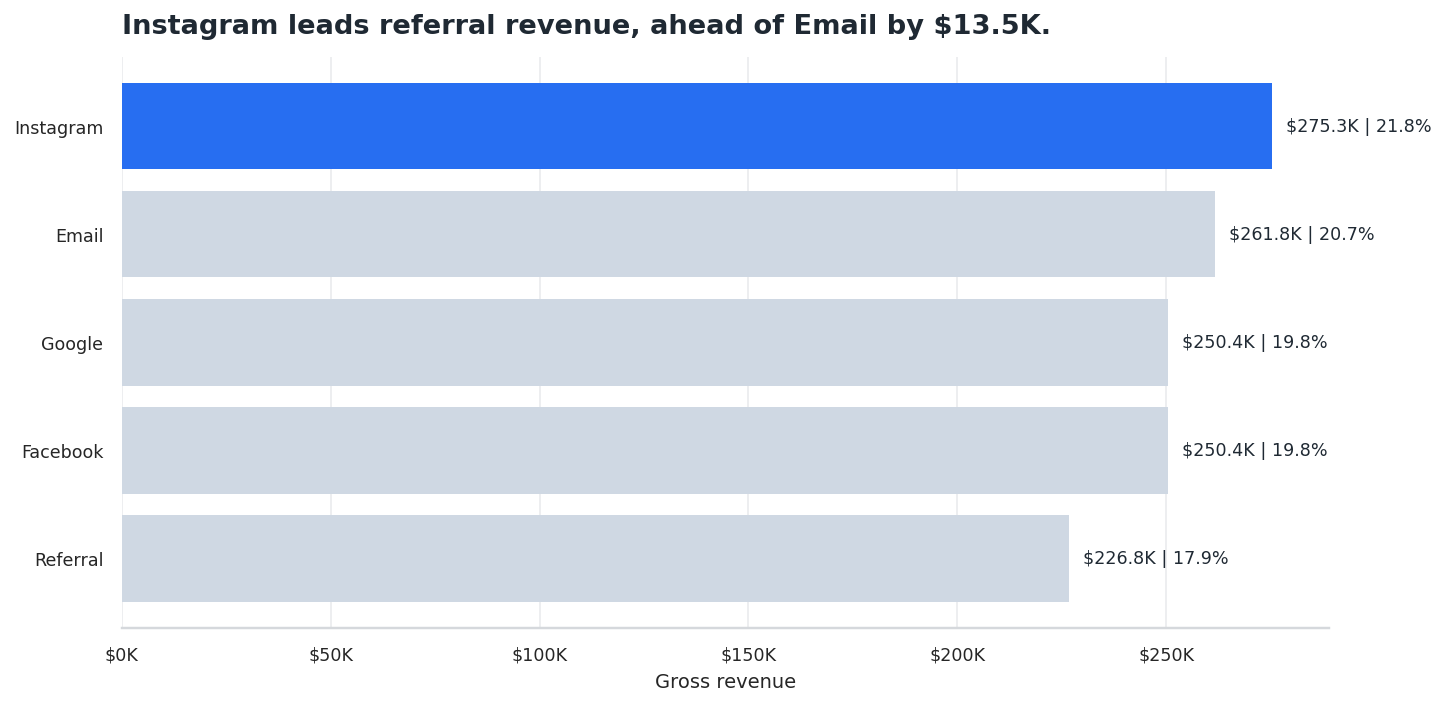

,ReferralSource,GrossRevenue,Orders,AverageOrderValue,RevenueShare
3,Instagram,275285.45,259,1062.878185,0.217658
0,Email,261808.55,250,1047.234200,0.207002
2,Google,250441.48,241,1039.176266,0.198015
1,Facebook,250410.90,228,1098.293421,0.197991
4,Referral,226815.58,222,1021.691802,0.179335


In [6]:
referral = (
    df.groupby('ReferralSource', as_index=False)
      .agg(GrossRevenue=('TotalPrice', 'sum'), Orders=('OrderID', 'count'), AverageOrderValue=('TotalPrice', 'mean'))
      .sort_values('GrossRevenue', ascending=False)
)
referral['RevenueShare'] = referral['GrossRevenue'] / referral['GrossRevenue'].sum()
lead_referral = referral.iloc[0]
second_referral = referral.iloc[1]
lead_gap = lead_referral['GrossRevenue'] - second_referral['GrossRevenue']

fig, ax = plt.subplots(figsize=(10.5, 5.2))
colors = [PALETTE['blue'] if src == lead_referral['ReferralSource'] else '#CFD8E3' for src in referral['ReferralSource']]
bars = ax.barh(referral['ReferralSource'], referral['GrossRevenue'], color=colors, edgecolor='none')
ax.invert_yaxis()
ax.set_title(f"{lead_referral['ReferralSource']} leads referral revenue, ahead of {second_referral['ReferralSource']} by {money_short(lead_gap)}.",
             loc='left', color=PALETTE['ink'], pad=12)
ax.set_xlabel('Gross revenue')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(money_millions))
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
for bar, value, share in zip(bars, referral['GrossRevenue'], referral['RevenueShare']):
    ax.text(value + referral['GrossRevenue'].max()*0.012, bar.get_y() + bar.get_height()/2,
            f'{money_short(value)} | {share:.1%}', va='center', fontsize=9, color=PALETTE['ink'])
fig.tight_layout()
referral_visual = VISUAL_DIR / '03_referral_revenue_contribution.png'
fig.savefig(referral_visual, bbox_inches='tight', facecolor='white')
plt.show()

referral

**Analyst note:** Referral contribution is not the same as channel ROI. The dataset does not include campaign spend, impressions, click-through rate, or acquisition cost.

## 5. Order Status Impact

**Story message:** Cancelled orders represent the largest single status bucket by gross listed value, making status resolution a priority for follow-up analysis.

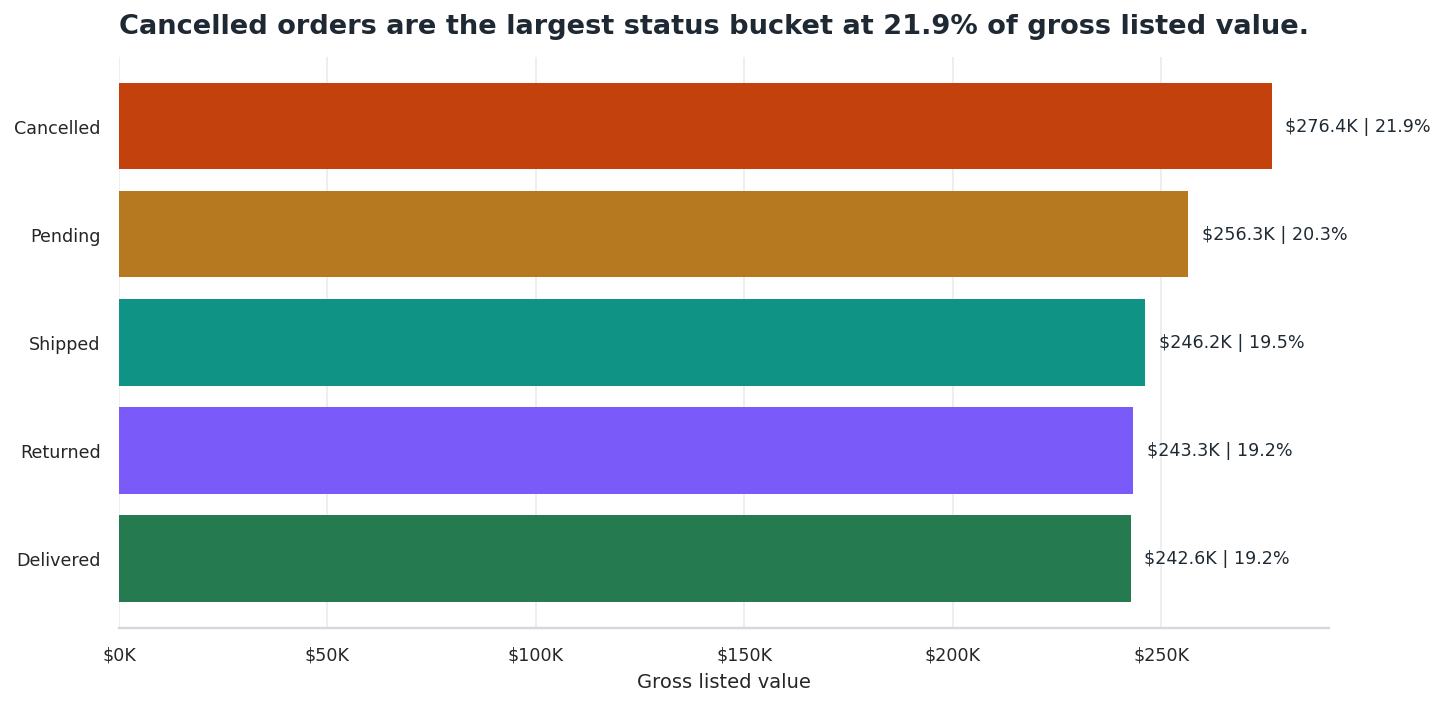

,OrderStatus,GrossRevenue,Orders,AverageOrderValue,RevenueShare
0,Cancelled,276396.21,250,1105.584840,0.218536
2,Pending,256328.15,237,1081.553376,0.202669
4,Shipped,246159.58,235,1047.487574,0.194629
3,Returned,243277.70,247,984.929960,0.192351
1,Delivered,242600.32,231,1050.217835,0.191815


In [7]:
status = (
    df.groupby('OrderStatus', as_index=False)
      .agg(GrossRevenue=('TotalPrice', 'sum'), Orders=('OrderID', 'count'), AverageOrderValue=('TotalPrice', 'mean'))
      .sort_values('GrossRevenue', ascending=False)
)
status['RevenueShare'] = status['GrossRevenue'] / status['GrossRevenue'].sum()
status_leader = status.iloc[0]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
status_colors = {
    'Cancelled': PALETTE['red'],
    'Pending': PALETTE['gold'],
    'Returned': '#7A5AF8',
    'Shipped': PALETTE['teal'],
    'Delivered': PALETTE['green'],
}
colors = [status_colors.get(s, PALETTE['gray']) for s in status['OrderStatus']]
bars = ax.barh(status['OrderStatus'], status['GrossRevenue'], color=colors, edgecolor='none')
ax.invert_yaxis()
ax.set_title(f"Cancelled orders are the largest status bucket at {status_leader['RevenueShare']:.1%} of gross listed value.",
             loc='left', color=PALETTE['ink'], pad=12)
ax.set_xlabel('Gross listed value')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(money_millions))
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
for bar, value, share in zip(bars, status['GrossRevenue'], status['RevenueShare']):
    ax.text(value + status['GrossRevenue'].max()*0.012, bar.get_y() + bar.get_height()/2,
            f'{money_short(value)} | {share:.1%}', va='center', fontsize=9, color=PALETTE['ink'])
fig.tight_layout()
status_visual = VISUAL_DIR / '04_order_status_revenue_impact.png'
fig.savefig(status_visual, bbox_inches='tight', facecolor='white')
plt.show()

status

**Analyst note:** This finding identifies where gross value is sitting by status. It does not prove lost revenue without a business rule for pending, cancelled, returned, shipped, and delivered order accounting.

## 6. Executive Recommendations

The recommendations below are limited to actions supported by the available fields.

In [8]:
metrics = {
    'date_range': f"{summary['date_min']} to {summary['date_max']}",
    'rows': int(summary['rows']),
    'gross_revenue': float(summary['gross_revenue']),
    'peak_month': peak_month['Month'].strftime('%b %Y'),
    'peak_month_revenue': float(peak_month['GrossRevenue']),
    'top_product': product.iloc[0]['Product'],
    'top_product_revenue': float(product.iloc[0]['GrossRevenue']),
    'second_product': product.iloc[1]['Product'],
    'top3_product_share': float(top3_share),
    'lead_referral': lead_referral['ReferralSource'],
    'lead_referral_revenue': float(lead_referral['GrossRevenue']),
    'lead_referral_share': float(lead_referral['RevenueShare']),
    'lead_referral_gap': float(lead_gap),
    'status_leader': status_leader['OrderStatus'],
    'status_leader_revenue': float(status_leader['GrossRevenue']),
    'status_leader_share': float(status_leader['RevenueShare']),
}

recommendations = pd.DataFrame([
    {
        'Priority': 'Status resolution',
        'Supported implication': f"{metrics['status_leader']} orders carry {pct(metrics['status_leader_share'])} of gross listed value.",
        'Recommended action': 'Investigate cancellation and return drivers by product and referral source before treating gross revenue as net performance.'
    },
    {
        'Priority': 'Product focus',
        'Supported implication': f"{metrics['top_product']} and {metrics['second_product']} are the leading revenue products; the top three products contribute {pct(metrics['top3_product_share'])} of revenue.",
        'Recommended action': 'Protect availability and merchandising for the top revenue products, while adding margin data before changing investment priorities.'
    },
    {
        'Priority': 'Referral channel review',
        'Supported implication': f"{metrics['lead_referral']} leads revenue contribution at {pct(metrics['lead_referral_share'])}, but spend data is unavailable.",
        'Recommended action': 'Use Instagram as a benchmark for creative and traffic quality, then add campaign spend to evaluate ROI.'
    },
    {
        'Priority': 'Revenue monitoring',
        'Supported implication': f"Monthly gross revenue peaks in {metrics['peak_month']} at {money_short(metrics['peak_month_revenue'])}.",
        'Recommended action': 'Compare peak months with campaign, inventory, and promotion calendars to determine whether spikes are repeatable.'
    },
])
recommendations

,Priority,Supported implication,Recommended action
0,Status resolution,Cancelled orders carry 21.9% of gross listed v...,Investigate cancellation and return drivers by...
1,Product focus,Chair and Printer are the leading revenue prod...,Protect availability and merchandising for the...
2,Referral channel review,"Instagram leads revenue contribution at 21.8%,...",Use Instagram as a benchmark for creative and ...
3,Revenue monitoring,Monthly gross revenue peaks in Jun 2024 at $68...,"Compare peak months with campaign, inventory, ..."


## 7. Generate Executive PowerPoint

The presentation is generated from the same metrics and chart images used above so the executive story remains consistent with the notebook.

In [9]:
# Helper functions for a clean executive deck.
SLIDE_W, SLIDE_H = 13.333, 7.5
prs = Presentation()
prs.slide_width = Inches(SLIDE_W)
prs.slide_height = Inches(SLIDE_H)
blank = prs.slide_layouts[6]

INK = RGBColor(31, 41, 51)
MUTED = RGBColor(102, 112, 133)
PAPER = RGBColor(250, 249, 246)
BLUE = RGBColor(39, 110, 241)
TEAL = RGBColor(14, 147, 132)
GOLD = RGBColor(183, 121, 31)
RED = RGBColor(194, 65, 12)
LIGHT = RGBColor(235, 238, 242)
WHITE = RGBColor(255, 255, 255)


def set_bg(slide, color=PAPER):
    fill = slide.background.fill
    fill.solid()
    fill.fore_color.rgb = color


def add_text(slide, text, x, y, w, h, size=18, color=INK, bold=False, align=PP_ALIGN.LEFT):
    box = slide.shapes.add_textbox(Inches(x), Inches(y), Inches(w), Inches(h))
    tf = box.text_frame
    tf.clear()
    tf.word_wrap = True
    tf.auto_size = MSO_AUTO_SIZE.TEXT_TO_FIT_SHAPE
    p = tf.paragraphs[0]
    p.alignment = align
    run = p.add_run()
    run.text = text
    run.font.name = 'Aptos'
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.color.rgb = color
    return box


def add_kicker(slide, text, num=None):
    label = f'{num:02d} / {text.upper()}' if num is not None else text.upper()
    add_text(slide, label, 0.65, 0.32, 3.8, 0.28, size=9, color=MUTED, bold=True)
    line = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(0.65), Inches(0.72), Inches(1.05), Inches(0.03))
    line.fill.solid(); line.fill.fore_color.rgb = BLUE
    line.line.fill.background()


def add_title(slide, claim, subtitle=None):
    add_text(slide, claim, 0.65, 0.82, 7.9, 0.95, size=27, color=INK, bold=True)
    if subtitle:
        add_text(slide, subtitle, 0.68, 1.70, 6.8, 0.45, size=11.5, color=MUTED)


def add_metric(slide, value, label, x, y, w=1.7, accent=BLUE):
    add_text(slide, value, x, y, w, 0.38, size=20, color=accent, bold=True)
    add_text(slide, label, x, y + 0.43, w, 0.38, size=8.5, color=MUTED)


def add_footer(slide, page):
    add_text(slide, 'Source: Dataset for Data Analytics.xlsx | Gross order value; not margin or ROI', 0.65, 7.05, 7.8, 0.22, size=7.5, color=MUTED)
    add_text(slide, f'{page:02d}', 12.25, 7.02, 0.5, 0.25, size=8, color=MUTED, align=PP_ALIGN.RIGHT)


def add_chart(slide, image_path, x=0.65, y=2.05, w=8.15, h=4.55):
    slide.shapes.add_picture(str(image_path), Inches(x), Inches(y), width=Inches(w), height=Inches(h))


def add_side_note(slide, title, bullets, x=9.15, y=2.12, w=3.45, h=4.35, accent=BLUE):
    shape = slide.shapes.add_shape(MSO_SHAPE.ROUNDED_RECTANGLE, Inches(x), Inches(y), Inches(w), Inches(h))
    shape.fill.solid(); shape.fill.fore_color.rgb = WHITE
    shape.line.color.rgb = LIGHT
    add_text(slide, title, x + 0.28, y + 0.25, w - 0.55, 0.35, size=13, color=accent, bold=True)
    yy = y + 0.78
    for bullet in bullets:
        add_text(slide, f'- {bullet}', x + 0.28, yy, w - 0.55, 0.5, size=10.5, color=INK)
        yy += 0.72

# Slide 1
slide = prs.slides.add_slide(blank); set_bg(slide)
add_text(slide, 'Executive Data Story', 0.75, 0.80, 7.8, 0.65, size=16, color=BLUE, bold=True)
add_text(slide, 'Gross revenue performance is broad-based, but status resolution is the clearest operational follow-up.', 0.75, 1.55, 9.8, 1.45, size=34, color=INK, bold=True)
add_text(slide, 'Project 4: Data Visualization and Executive Communication', 0.78, 3.10, 6.8, 0.35, size=13, color=MUTED)
add_metric(slide, f"${metrics['gross_revenue']/1_000_000:.2f}M", 'gross order value', 0.78, 4.20, accent=BLUE)
add_metric(slide, f"{metrics['rows']:,}", 'orders analyzed', 2.85, 4.20, accent=TEAL)
add_metric(slide, metrics['date_range'], 'observed period', 4.85, 4.20, w=2.7, accent=GOLD)
add_metric(slide, f"{metrics['status_leader_share']:.1%}", f"gross value in {metrics['status_leader']}", 7.95, 4.20, w=2.5, accent=RED)
add_footer(slide, 1)

# Slide 2
slide = prs.slides.add_slide(blank); set_bg(slide); add_kicker(slide, 'Revenue Story', 2)
add_title(slide, 'Monthly revenue has peaks, but no sustained upward trend.', f"Peak month: {metrics['peak_month']} at {money_short(metrics['peak_month_revenue'])} gross revenue.")
add_chart(slide, revenue_visual)
add_side_note(slide, 'Readout', [
    'Revenue fluctuates around a variable baseline.',
    'The 3-month average helps separate signal from monthly noise.',
    'Use campaign and inventory calendars to explain peaks.'
], accent=BLUE)
add_footer(slide, 2)

# Slide 3
slide = prs.slides.add_slide(blank); set_bg(slide); add_kicker(slide, 'Product Performance', 3)
add_title(slide, f"{metrics['top_product']} and {metrics['second_product']} anchor product revenue.", f"Top three products generate {metrics['top3_product_share']:.1%} of gross revenue.")
add_chart(slide, product_visual)
add_side_note(slide, 'Implication', [
    'Product mix matters more than simple order counts.',
    'Top-product availability should be protected.',
    'Margin data is needed before investment shifts.'
], accent=TEAL)
add_footer(slide, 3)

# Slide 4
slide = prs.slides.add_slide(blank); set_bg(slide); add_kicker(slide, 'Referral Sources', 4)
add_title(slide, f"{metrics['lead_referral']} leads revenue contribution, but the field is balanced.", f"Lead over the second-ranked source is {money_short(metrics['lead_referral_gap'])}.")
add_chart(slide, referral_visual)
add_side_note(slide, 'Implication', [
    'Instagram is the highest gross-revenue source.',
    'The lead is meaningful but not dominant.',
    'ROI cannot be evaluated without spend data.'
], accent=BLUE)
add_footer(slide, 4)

# Slide 5
slide = prs.slides.add_slide(blank); set_bg(slide); add_kicker(slide, 'Order Status', 5)
add_title(slide, f"{metrics['status_leader']} orders are the largest gross-value status bucket.", 'Status mix should be resolved before leadership treats gross revenue as net performance.')
add_chart(slide, status_visual)
add_side_note(slide, 'Implication', [
    'Cancelled value is the top single status bucket.',
    'Pending and returned orders also need business rules.',
    'The file does not contain a Completed label.'
], accent=RED)
add_footer(slide, 5)

# Slide 6
slide = prs.slides.add_slide(blank); set_bg(slide); add_kicker(slide, 'Recommendations', 6)
add_title(slide, 'The next best actions improve revenue quality, not just revenue reporting.')
rows = [
    ('Resolve order status', 'Investigate cancellation, return, and pending drivers by product and referral source.', RED),
    ('Protect leading products', 'Maintain availability for top revenue products while adding margin data.', TEAL),
    ('Benchmark Instagram', 'Use the lead channel as a creative benchmark, then add spend for ROI analysis.', BLUE),
    ('Explain revenue peaks', 'Match peak months to campaign, promotion, and inventory calendars.', GOLD),
]
y = 2.05
for title, body, color in rows:
    marker = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(0.78), Inches(y + 0.08), Inches(0.08), Inches(0.62))
    marker.fill.solid(); marker.fill.fore_color.rgb = color
    marker.line.fill.background()
    add_text(slide, title, 1.05, y, 3.1, 0.35, size=15, color=INK, bold=True)
    add_text(slide, body, 4.10, y - 0.02, 7.7, 0.55, size=13, color=MUTED)
    y += 0.93
add_footer(slide, 6)

# Slide 7
slide = prs.slides.add_slide(blank); set_bg(slide)
add_text(slide, 'Closing View', 0.75, 0.85, 3.0, 0.45, size=16, color=BLUE, bold=True)
add_text(slide, 'This dataset supports a clear gross-revenue story, but better executive decisions require net revenue, margin, spend, and status-resolution detail.', 0.75, 1.55, 10.2, 1.55, size=31, color=INK, bold=True)
add_text(slide, 'Recommended data additions: cost and margin, channel spend, cancellation reason, return reason, fulfillment milestone dates, and a formal completed-order definition.', 0.80, 3.55, 9.2, 0.85, size=15, color=MUTED)
add_footer(slide, 7)

pptx_path = PRESENTATION_DIR / 'Executive_Data_Story.pptx'
prs.save(pptx_path)
pptx_path

WindowsPath('D:/Mark/Internships/DecodeLabs-Internship/Project-4-Data-Visualization/presentation/Executive_Data_Story.pptx')

## Final Output Checklist

This notebook creates the four selected visuals and the executive PowerPoint deck. The HTML report is generated separately through `nbconvert` after successful execution.

In [10]:
outputs = {
    'visuals': [
        str(revenue_visual.relative_to(BASE_DIR)),
        str(product_visual.relative_to(BASE_DIR)),
        str(referral_visual.relative_to(BASE_DIR)),
        str(status_visual.relative_to(BASE_DIR)),
    ],
    'presentation': str((PRESENTATION_DIR / 'Executive_Data_Story.pptx').relative_to(BASE_DIR)),
    'key_findings': {
        'gross_revenue': f"${metrics['gross_revenue']:,.2f}",
        'top_product': metrics['top_product'],
        'lead_referral': metrics['lead_referral'],
        'largest_status_bucket': metrics['status_leader'],
        'important_limitation': 'No cost, margin, channel spend, or cancellation reason fields are available.'
    }
}
outputs

{'visuals': ['visuals\\01_monthly_revenue_trend.png',
  'visuals\\02_product_revenue_ranking.png',
  'visuals\\03_referral_revenue_contribution.png',
  'visuals\\04_order_status_revenue_impact.png'],
 'presentation': 'presentation\\Executive_Data_Story.pptx',
 'key_findings': {'gross_revenue': '$1,264,761.96',
  'top_product': 'Chair',
  'lead_referral': 'Instagram',
  'largest_status_bucket': 'Cancelled',
  'important_limitation': 'No cost, margin, channel spend, or cancellation reason fields are available.'}}